# 14. Modelado Predictivo de Demanda — Iteración 9: Mejoras Inmediatas

## Mejoras sobre It7: Features Temporales + Lags Extendidos + Modelo Hurdle para B/C

Esta iteración implementa las **cinco mejoras inmediatas** recomendadas por el análisis técnico del Head of Data, utilizando **únicamente los datasets ya disponibles** — sin necesidad de datos externos adicionales.

| Mejora | Descripción | Impacto Esperado |
|---|---|---|
| **A3** | Features temporales cíclicas y granulares | Captura estacionalidad intra-mes |
| **A4** | Lags extendidos + ventanas de rolling ampliadas | Señales de momentum a corto y largo plazo |
| **A5** | Features de tendencia local (ratio YoY, tendencia 4v4) | Detecta si el SKU está en racha o cayendo |
| **A1** | Modelo Hurdle para B/C (clasificación + regresión) | Separa "¿habrá venta?" de "¿cuánto?" |
| **A2** | Tweedie loss como alternativa al Hurdle | Benchmark nativo para distribución con ceros |

**Dataset base:** `df_final_modelado_it6.csv` (mismo que It7)
**Comparativa referencia:** It7 → MAE 0.628 | MAPE 21.5%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Carga del Dataset

Usamos `df_final_modelado_it6.csv` — el mismo punto de partida que It7, con variables de descuento ya incorporadas.

In [2]:
df = pd.read_csv('../Datasets/df_final_modelado_it6.csv', sep=';')

REGION_MAP = {
    'A CORUÑA': 'Noroeste', 'LUGO': 'Noroeste', 'OURENSE': 'Noroeste',
    'PONTEVEDRA': 'Noroeste', 'ASTURIAS': 'Noroeste', 'CANTABRIA': 'Noroeste',
    'ALAVA': 'Norte', 'GIPUZKOA': 'Norte', 'VIZCAYA': 'Norte',
    'NAVARRA': 'Norte', 'LA RIOJA': 'Norte', 'HUESCA': 'Norte',
    'ZARAGOZA': 'Norte', 'TERUEL': 'Norte',
    'BARCELONA': 'Noreste', 'GIRONA': 'Noreste', 'LLEIDA': 'Noreste',
    'TARRAGONA': 'Noreste', 'CASTELLON': 'Noreste', 'VALENCIA': 'Noreste',
    'ALICANTE': 'Noreste', 'ILLES BALEARS': 'Noreste',
    'MADRID': 'Centro', 'TOLEDO': 'Centro', 'CUENCA': 'Centro',
    'GUADALAJARA': 'Centro', 'CIUDAD REAL': 'Centro', 'ALBACETE': 'Centro',
    'BURGOS': 'Centro', 'SEGOVIA': 'Centro', 'SORIA': 'Centro',
    'VALLADOLID': 'Centro', 'AVILA': 'Centro', 'SALAMANCA': 'Centro',
    'ZAMORA': 'Centro', 'LEON': 'Centro', 'PALENCIA': 'Centro',
    'CACERES': 'Centro', 'BADAJOZ': 'Centro',
    'SEVILLA': 'Sur', 'MALAGA': 'Sur', 'GRANADA': 'Sur', 'CORDOBA': 'Sur',
    'JAEN': 'Sur', 'HUELVA': 'Sur', 'CADIZ': 'Sur', 'ALMERIA': 'Sur',
    'MURCIA': 'Sur',
    'LAS PALMAS': 'Canarias', 'SANTA CRUZ DE TENERIFE': 'Canarias',
}
df['region'] = df['Provincia'].map(REGION_MAP).fillna('Centro')

df = df.sort_values(['codigo_articulo', 'Municipio', 'anio', 'semana_anio']).reset_index(drop=True)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Periodo: {df['anio'].min()}–{df['anio'].max()}")
print(f"SKUs únicos: {df['codigo_articulo'].nunique():,}  |  Municipios: {df['Municipio'].nunique():,}")

Dataset cargado: 252,836 filas × 22 columnas
Periodo: 2022–2024
SKUs únicos: 2,424  |  Municipios: 809


---
## 2. Feature Engineering Extendido (A3 + A4 + A5)

### A3 — Features Temporales Cíclicas y Granulares

El dataset solo tenía `semana_anio` como variable temporal. Añadimos:
- **Mes y trimestre**: capturan estacionalidad mensual
- **Semana del mes**: detecta si es fin de mes (spikes de cierre de pedidos)
- **Encoding cíclico (sin/cos)**: representación continua de la semana — la semana 52 y la 1 son "vecinas"

### A4 — Lags Extendidos y Ventanas de Rolling Ampliadas

It7 tenía solo lag 1 semana y lag 4 semanas. Añadimos:
- **Lags adicionales**: 2, 3, 6, 8, 12 semanas (señal a corto-medio plazo)
- **Rolling mean** ampliado: ventanas de 2, 6, 12 semanas
- **Rolling std**: volatilidad a 4, 8 y 12 semanas — ¿está el SKU en un periodo errático?

### A5 — Features de Tendencia Local

- **Tendencia 4v4**: ratio entre la media de las últimas 4 semanas vs las 4 anteriores (¿acelerando o desacelerando?)
- **Ratio YoY**: unidades actuales vs mismo periodo año anterior (¿crecimiento interanual?)

In [3]:
# ── A3: Features temporales cíclicas ────────────────────────────────────────
def semana_to_mes(semana):
    """Aproximación: mes del año a partir de la semana ISO."""
    return np.clip(((semana - 1) // 4) + 1, 1, 12)

df['mes']            = semana_to_mes(df['semana_anio'])
df['trimestre']      = ((df['mes'] - 1) // 3) + 1
df['semana_del_mes'] = ((df['semana_anio'] - 1) % 4) + 1   # 1–4
df['es_fin_mes']     = (df['semana_del_mes'] == 4).astype(int)
df['sin_semana']     = np.sin(2 * np.pi * df['semana_anio'] / 52)
df['cos_semana']     = np.cos(2 * np.pi * df['semana_anio'] / 52)

print("A3 — Features temporales añadidas:", ['mes', 'trimestre', 'semana_del_mes',
                                              'es_fin_mes', 'sin_semana', 'cos_semana'])

# ── A4: Lags extendidos ──────────────────────────────────────────────────────
GROUP_KEY = ['codigo_articulo', 'Municipio']

for lag in [2, 3, 6, 8, 12]:
    col = f'unidades_lag_{lag}sem'
    df[col] = df.groupby(GROUP_KEY)['unidades'].shift(lag)

print(f"A4 — Lags añadidos: {[f'unidades_lag_{l}sem' for l in [2,3,6,8,12]]}")

# ── A4: Rolling mean ampliado ────────────────────────────────────────────────
for w in [2, 6, 12]:
    col = f'unidades_rolling_mean_{w}sem'
    df[col] = (df.groupby(GROUP_KEY)['unidades']
                 .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean()))

# ── A4: Rolling std (volatilidad) ────────────────────────────────────────────
for w in [4, 8, 12]:
    col = f'unidades_rolling_std_{w}sem'
    df[col] = (df.groupby(GROUP_KEY)['unidades']
                 .transform(lambda x: x.shift(1).rolling(w, min_periods=2).std().fillna(0)))

print(f"A4 — Rolling mean: {[f'rolling_mean_{w}sem' for w in [2,6,12]]}")
print(f"A4 — Rolling std:  {[f'rolling_std_{w}sem' for w in [4,8,12]]}")

# ── A5: Tendencia 4v4 ────────────────────────────────────────────────────────
roll4  = df.groupby(GROUP_KEY)['unidades'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
roll8  = df.groupby(GROUP_KEY)['unidades'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
roll4b = roll8 - roll4  # media de las 4 semanas previas al bloque reciente
df['tendencia_4v4'] = roll4 / (roll4b.replace(0, np.nan)).fillna(1).clip(0.1, 10)

# ── A5: Ratio YoY ────────────────────────────────────────────────────────────
if 'unidades_misma_semana_anio_anterior' in df.columns:
    df['ratio_yoy'] = df['unidades'] / (df['unidades_misma_semana_anio_anterior'] + 0.1)
    df['ratio_yoy'] = df['ratio_yoy'].clip(0, 20)
    print("A5 — ratio_yoy calculado sobre lag interanual existente")
else:
    df['ratio_yoy'] = 1.0
    print("A5 — ratio_yoy: lag interanual no encontrado, imputado a 1.0")

print("A5 — tendencia_4v4 calculada")

# ── Rellenar NaN de nuevos lags ──────────────────────────────────────────────
new_lag_cols = [c for c in df.columns if 'lag_' in c or 'rolling_' in c or c in ['tendencia_4v4', 'ratio_yoy']]
df[new_lag_cols] = df[new_lag_cols].fillna(0)

print(f"\nTotal features nuevas añadidas en It9: {len(new_lag_cols)}")
print(f"Shape final del dataset: {df.shape}")

A3 — Features temporales añadidas: ['mes', 'trimestre', 'semana_del_mes', 'es_fin_mes', 'sin_semana', 'cos_semana']
A4 — Lags añadidos: ['unidades_lag_2sem', 'unidades_lag_3sem', 'unidades_lag_6sem', 'unidades_lag_8sem', 'unidades_lag_12sem']
A4 — Rolling mean: ['rolling_mean_2sem', 'rolling_mean_6sem', 'rolling_mean_12sem']
A4 — Rolling std:  ['rolling_std_4sem', 'rolling_std_8sem', 'rolling_std_12sem']
A5 — ratio_yoy: lag interanual no encontrado, imputado a 1.0
A5 — tendencia_4v4 calculada

Total features nuevas añadidas en It9: 15
Shape final del dataset: (252836, 41)


---
## 3. Target, Features y Split Temporal

In [4]:
# ── Target log1p ────────────────────────────────────────────────────────────
df['unidades_log'] = np.log1p(df['unidades'])

# ── Target binario para Hurdle ───────────────────────────────────────────────
df['hubo_venta'] = (df['unidades'] > 0).astype(int)

# ── Precio unitario ──────────────────────────────────────────────────────────
df['precio_unitario'] = (df['importe_neto'] / df['unidades'].replace(0, np.nan)).fillna(0)

# ── Temporada alta ───────────────────────────────────────────────────────────
df['es_temporada_alta'] = df['semana_anio'].between(10, 22) | df['semana_anio'].between(35, 48)
df['es_temporada_alta'] = df['es_temporada_alta'].astype(int)

# ── Lista de features ────────────────────────────────────────────────────────
cat_features = ['Provincia', 'Municipio', 'codigo_articulo',
                'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'region']

num_features_base = [
    # Temporales base
    'semana_anio', 'anio', 'es_temporada_alta',
    # Temporales nuevas (A3)
    'mes', 'trimestre', 'semana_del_mes', 'es_fin_mes', 'sin_semana', 'cos_semana',
    # Precio
    'precio_unitario',
    # Lags existentes (It7)
    'unidades_lag_1_semana', 'unidades_lag_1_mes',
    # Lags nuevos (A4)
    'unidades_lag_2sem', 'unidades_lag_3sem', 'unidades_lag_6sem',
    'unidades_lag_8sem', 'unidades_lag_12sem',
    # Rolling existente (It7) — si existe
    # Rolling nuevos (A4)
    'unidades_rolling_mean_2sem', 'unidades_rolling_mean_6sem', 'unidades_rolling_mean_12sem',
    'unidades_rolling_std_4sem', 'unidades_rolling_std_8sem', 'unidades_rolling_std_12sem',
    # Tendencia (A5)
    'tendencia_4v4', 'ratio_yoy',
    # Externas
    'temp_media', 'precip_mm', 'viento_max',
    'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista',
    'valor_descuento_promo', 'hubo_descuento_promo',
]

# Añadir columnas que existan en el dataframe y no estén ya listadas
extra_cols = ['unidades_sliding_window_mensual', 'unidades_misma_semana_anio_anterior',
              'tendencia_unidades', 'volatilidad_4_sem',
              'interaccion_region_temp', 'interaccion_region_precip']
for col in extra_cols:
    if col in df.columns and col not in num_features_base:
        num_features_base.append(col)

# Filtrar a las que realmente existen en df
num_features = [f for f in num_features_base if f in df.columns]
all_features = num_features + cat_features

print(f"Total features numéricas: {len(num_features)}")
print(f"Total features categóricas: {len(cat_features)}")
print(f"Total features modelo: {len(all_features)}")
print(f"  → +{len(num_features) - 17} features nuevas respecto a It7 (estimado)")

# ── Split temporal ───────────────────────────────────────────────────────────
df_train_all = df[df['anio'] < 2024].copy()
df_test_all  = df[df['anio'] == 2024].copy()

# ── Split por segmento ───────────────────────────────────────────────────────
df_train_A   = df_train_all[df_train_all['tipo_abc'] == 'A'].copy()
df_train_BC  = df_train_all[df_train_all['tipo_abc'] != 'A'].copy()
df_test_A    = df_test_all[df_test_all['tipo_abc'] == 'A'].copy()
df_test_BC   = df_test_all[df_test_all['tipo_abc'] != 'A'].copy()

print(f"\nTrain total: {len(df_train_all):,}  |  Test total: {len(df_test_all):,}")
print(f"Train A: {len(df_train_A):,}  |  Train B&C: {len(df_train_BC):,}")
print(f"Test  A: {len(df_test_A):,}   |  Test  B&C: {len(df_test_BC):,}")
print(f"\n% semanas con venta (B&C train): {df_train_BC['hubo_venta'].mean()*100:.1f}%")
print(f"% semanas con venta (A train):   {df_train_A['hubo_venta'].mean()*100:.1f}%")

Total features numéricas: 33
Total features categóricas: 7
Total features modelo: 40
  → +16 features nuevas respecto a It7 (estimado)

Train total: 180,718  |  Test total: 72,118
Train A: 128,745  |  Train B&C: 51,973
Test  A: 50,025   |  Test  B&C: 22,093

% semanas con venta (B&C train): 100.0%
% semanas con venta (A train):   100.0%


---
## 4. Target Encoding por Segmento

Mismo método que It7: expanding mean con shift(1) para evitar data leakage. Se calcula independientemente dentro de cada segmento.

In [5]:
def target_encoding_expanding(df_seg, group_cols, target_col, new_col_name):
    """Expanding mean con shift(1) — sin leakage temporal."""
    df_seg = df_seg.sort_values(['anio', 'semana_anio'])
    enc = (df_seg.groupby(group_cols)[target_col]
                 .transform(lambda x: x.shift(1).expanding().mean()))
    global_mean = df_seg[target_col].mean()
    df_seg[new_col_name] = enc.fillna(global_mean)
    return df_seg

# Calcular sobre el dataset completo (train+test en orden temporal)
for seg_label, mask in [('A', df['tipo_abc'] == 'A'), ('BC', df['tipo_abc'] != 'A')]:
    idx = df[mask].index
    seg = df.loc[idx].copy()
    seg = target_encoding_expanding(seg, ['codigo_articulo', 'Municipio'],
                                    'unidades_log', 'te_sku_municipio')
    seg = target_encoding_expanding(seg, ['Municipio'],
                                    'unidades_log', 'te_municipio')
    df.loc[idx, 'te_sku_municipio'] = seg['te_sku_municipio'].values
    df.loc[idx, 'te_municipio']     = seg['te_municipio'].values

# Añadir a la lista de features
for te_col in ['te_sku_municipio', 'te_municipio']:
    if te_col not in num_features:
        num_features.append(te_col)
        all_features.append(te_col)

# Rehacer splits con encoding incluido
df_train_all = df[df['anio'] < 2024].copy()
df_test_all  = df[df['anio'] == 2024].copy()
df_train_A   = df_train_all[df_train_all['tipo_abc'] == 'A'].copy()
df_train_BC  = df_train_all[df_train_all['tipo_abc'] != 'A'].copy()
df_test_A    = df_test_all[df_test_all['tipo_abc'] == 'A'].copy()
df_test_BC   = df_test_all[df_test_all['tipo_abc'] != 'A'].copy()

print("Target encoding calculado para ambos segmentos.")
print(f"te_sku_municipio — media segmento A: {df_train_A['te_sku_municipio'].mean():.3f}")
print(f"te_sku_municipio — media segmento BC: {df_train_BC['te_sku_municipio'].mean():.3f}")

Target encoding calculado para ambos segmentos.
te_sku_municipio — media segmento A: 0.889
te_sku_municipio — media segmento BC: 0.856


---
## 5. Funciones Auxiliares

In [6]:
def metricas(y_real, y_pred, label=''):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - y_real.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    mask = y_real > 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    return {'Label': label, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

def make_objective_reg(X_tr, y_tr, cat_feats, loss='MAE'):
    """Función objetivo Optuna para CatBoostRegressor."""
    tscv = TimeSeriesSplit(n_splits=3)
    def objective(trial):
        params = {
            'iterations'        : 600,
            'learning_rate'     : trial.suggest_float('learning_rate', 0.03, 0.3, log=True),
            'depth'             : trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1, 30, log=True),
            'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 10, 150),
            'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'loss_function'     : loss,
            'eval_metric'       : 'MAE',
            'random_seed'       : 42,
            'verbose'           : 0,
        }
        scores = []
        for tr_idx, val_idx in tscv.split(X_tr):
            X_t, X_v = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
            y_t, y_v = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
            m = CatBoostRegressor(**params)
            m.fit(X_t, y_t, cat_features=cat_feats, eval_set=(X_v, y_v),
                  early_stopping_rounds=50, verbose=0)
            preds = np.maximum(np.expm1(m.predict(X_v)), 0)
            scores.append(mean_absolute_error(np.expm1(y_v), preds))
        return np.mean(scores)
    return objective

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


---
## 6. Modelo A — CatBoost con Features Extendidas

Para el segmento Tipo A mantenemos la arquitectura de It7 (CatBoostRegressor + log1p target) pero ahora con el conjunto ampliado de features temporales, lags y tendencia. Ejecutamos Optuna con 30 trials para re-optimizar hiperparámetros sobre el nuevo espacio de features.

In [7]:
X_train_A = df_train_A[all_features]
y_train_A = df_train_A['unidades_log']
X_test_A  = df_test_A[all_features]
y_real_test_A = df_test_A['unidades'].values

print("Optimizando Modelo A (30 trials)...")
study_A = optuna.create_study(direction='minimize',
                               sampler=optuna.samplers.TPESampler(seed=42))
study_A.optimize(make_objective_reg(X_train_A, y_train_A, cat_features),
                 n_trials=30, show_progress_bar=True)

best_params_A = study_A.best_params
print(f"\nMejores hiperparámetros Modelo A (It9):")
for k, v in best_params_A.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"MAE CV (escala original): {study_A.best_value:.4f}")

Optimizando Modelo A (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Mejores hiperparámetros Modelo A (It9):
  learning_rate: 0.1033
  depth: 5
  l2_leaf_reg: 3.3379
  min_data_in_leaf: 47
  subsample: 0.7558
  colsample_bylevel: 0.9172
MAE CV (escala original): 0.5624


In [8]:
params_A = {
    'iterations'        : 1000,
    'learning_rate'     : best_params_A['learning_rate'],
    'depth'             : best_params_A['depth'],
    'l2_leaf_reg'       : best_params_A['l2_leaf_reg'],
    'min_data_in_leaf'  : best_params_A['min_data_in_leaf'],
    'subsample'         : best_params_A['subsample'],
    'colsample_bylevel' : best_params_A['colsample_bylevel'],
    'loss_function'     : 'MAE',
    'eval_metric'       : 'MAE',
    'random_seed'       : 42,
    'verbose'           : 100,
}

modelo_A = CatBoostRegressor(**params_A)
modelo_A.fit(X_train_A, y_train_A, cat_features=cat_features,
             eval_set=(X_test_A, df_test_A['unidades_log']),
             early_stopping_rounds=50)

# Predicciones
y_pred_train_A = np.maximum(np.expm1(modelo_A.predict(X_train_A)), 0)
y_pred_test_A  = np.maximum(np.expm1(modelo_A.predict(X_test_A)), 0)

m_train_A = metricas(df_train_A['unidades'].values, y_pred_train_A, 'A Train')
m_test_A  = metricas(y_real_test_A, y_pred_test_A, 'A Test')
brecha_A  = (m_test_A['RMSE'] - m_train_A['RMSE']) / m_train_A['RMSE'] * 100

print(f"\n{'─'*50}")
print(f"MODELO A (It9) — TEST 2024")
print(f"  MAE:  {m_test_A['MAE']:.4f}  |  MAPE: {m_test_A['MAPE']:.2f}%")
print(f"  RMSE: {m_test_A['RMSE']:.4f}  |  R²:   {m_test_A['R2']:.3f}")
print(f"  Brecha overfitting (RMSE): +{brecha_A:.1f}%")
print(f"  Referencia It7 A → MAE: 0.676 | MAPE: 22.2%")

0:	learn: 0.1677442	test: 0.1672502	best: 0.1672502 (0)	total: 166ms	remaining: 2m 45s
100:	learn: 0.1458748	test: 0.1466640	best: 0.1466640 (100)	total: 8.75s	remaining: 1m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1465512627
bestIteration = 112

Shrink model to first 113 iterations.

──────────────────────────────────────────────────
MODELO A (It9) — TEST 2024
  MAE:  0.6635  |  MAPE: 18.90%
  RMSE: 3.7625  |  R²:   0.188
  Brecha overfitting (RMSE): +25.1%
  Referencia It7 A → MAE: 0.676 | MAPE: 22.2%


---
## 7. Modelo B/C — Estrategia corregida

### Por qué el Hurdle no aplica

El dataset solo contiene semanas **con ventas** (`hubo_venta = 1` en el 100% de B/C). Un Hurdle model necesita semanas en cero para aprender "¿cuándo NO habrá venta?". Construir el panel completo generaría ~130M filas — inviable a esta granularidad.

### Por qué Tweedie + log1p es incompatible

La versión anterior cometió un error de doble transformación:

```
INCORRECTO:  target = log1p(unidades)  +  loss = Tweedie
             ↑ ya gestiona asimetría      ↑ ya gestiona asimetría → se anulan

CORRECTO:    target = log1p(unidades)  +  loss = MAE      (como It7)
    ó:       target = unidades         +  loss = Tweedie   (escala original)
```

### Dos opciones implementadas y comparadas

- **Opción 1 — MAE + log1p** (misma arquitectura que It7, ahora con las nuevas features A3/A4/A5): benchmark mínimo esperado
- **Opción 2 — Tweedie + target original**: Tweedie gestiona internamente la distribución asimétrica sin necesidad de log1p

In [20]:
# ── Datos B/C ────────────────────────────────────────────────────────────────
X_train_BC     = df_train_BC[all_features]
y_train_BC_log = df_train_BC['unidades_log']
X_test_BC      = df_test_BC[all_features]
y_real_test_BC = df_test_BC['unidades'].values

print(f"Train B&C: {len(X_train_BC):,} filas  |  Test B&C: {len(X_test_BC):,} filas")
print(f"Distribución unidades B&C (train): media={df_train_BC['unidades'].mean():.2f} | "
      f"mediana={df_train_BC['unidades'].median():.1f} | max={df_train_BC['unidades'].max():.0f}")
print("→ Confirmado: dataset sin filas de cero demanda. Aplicamos Tweedie loss (A2).")

Train B&C: 51,973 filas  |  Test B&C: 22,093 filas
Distribución unidades B&C (train): media=1.58 | mediana=1.0 | max=400
→ Confirmado: dataset sin filas de cero demanda. Aplicamos Tweedie loss (A2).


---
## 8. Modelo B/C — Opción 1: MAE + log1p (misma arquitectura que It7, nuevas features)

In [21]:
print("Optimizando Modelo B/C — Opción 1: MAE + log1p (30 trials)...")

study_mae = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_mae.optimize(
    make_objective_reg(X_train_BC, y_train_BC_log, cat_features, loss='MAE'),
    n_trials=30, show_progress_bar=True)

best_params_mae = study_mae.best_params
print(f"\nMejores hiperparámetros B/C MAE+log1p:")
for k, v in best_params_mae.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"MAE CV (escala original): {study_mae.best_value:.4f}")

Optimizando Modelo B/C — Opción 1: MAE + log1p (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Mejores hiperparámetros B/C MAE+log1p:
  learning_rate: 0.2958
  depth: 4
  l2_leaf_reg: 2.9837
  min_data_in_leaf: 67
  subsample: 0.8101
  colsample_bylevel: 0.6374
MAE CV (escala original): 0.4808


In [22]:
params_mae_bc = {
    'iterations'        : 1000,
    'learning_rate'     : best_params_mae['learning_rate'],
    'depth'             : best_params_mae['depth'],
    'l2_leaf_reg'       : best_params_mae['l2_leaf_reg'],
    'min_data_in_leaf'  : best_params_mae['min_data_in_leaf'],
    'subsample'         : best_params_mae['subsample'],
    'colsample_bylevel' : best_params_mae['colsample_bylevel'],
    'loss_function'     : 'MAE',
    'eval_metric'       : 'MAE',
    'random_seed'       : 42,
    'verbose'           : 100,
}

modelo_BC_mae = CatBoostRegressor(**params_mae_bc)
modelo_BC_mae.fit(X_train_BC, y_train_BC_log, cat_features=cat_features,
                  eval_set=(X_test_BC, df_test_BC['unidades_log']),
                  early_stopping_rounds=50)

y_pred_train_BC_mae = np.maximum(np.expm1(modelo_BC_mae.predict(X_train_BC)), 0)
y_pred_test_BC_mae  = np.maximum(np.expm1(modelo_BC_mae.predict(X_test_BC)), 0)

m_train_BC_mae = metricas(df_train_BC['unidades'].values, y_pred_train_BC_mae, 'BC MAE train')
m_test_BC_mae  = metricas(y_real_test_BC, y_pred_test_BC_mae, 'BC MAE test')
brecha_mae_bc  = (m_test_BC_mae['RMSE'] - m_train_BC_mae['RMSE']) / m_train_BC_mae['RMSE'] * 100

print(f"\n{'─'*50}")
print(f"MODELO B/C — Opción 1 MAE+log1p — TEST 2024")
print(f"  MAE:  {m_test_BC_mae['MAE']:.4f}  |  MAPE: {m_test_BC_mae['MAPE']:.2f}%")
print(f"  RMSE: {m_test_BC_mae['RMSE']:.4f}  |  R²:   {m_test_BC_mae['R2']:.3f}")
print(f"  Brecha overfitting (RMSE): +{brecha_mae_bc:.1f}%")
print(f"  Referencia It7 B/C → MAE: 0.521 | MAPE: 18.9%")

# ── Opción 2: Tweedie sobre target ORIGINAL (sin log1p) ──────────────────────
print(f"\n{'─'*50}")
print("Optimizando Modelo B/C — Opción 2: Tweedie + target original (20 trials)...")

def make_objective_tweedie_raw(X_tr, y_tr_raw, cat_feats):
    """Objetivo Optuna para Tweedie sobre escala original."""
    tscv = TimeSeriesSplit(n_splits=3)
    def objective(trial):
        params = {
            'iterations'        : 600,
            'learning_rate'     : trial.suggest_float('learning_rate', 0.03, 0.3, log=True),
            'depth'             : trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1, 30, log=True),
            'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 10, 150),
            'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'loss_function'     : 'Tweedie:variance_power=1.5',
            'eval_metric'       : 'MAE',
            'random_seed'       : 42,
            'verbose'           : 0,
        }
        scores = []
        for tr_idx, val_idx in tscv.split(X_tr):
            X_t, X_v = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
            y_t, y_v = y_tr_raw.iloc[tr_idx], y_tr_raw.iloc[val_idx]
            m = CatBoostRegressor(**params)
            m.fit(X_t, y_t, cat_features=cat_feats, eval_set=(X_v, y_v),
                  early_stopping_rounds=50, verbose=0)
            preds = np.maximum(m.predict(X_v), 0)          # ya en escala original
            scores.append(mean_absolute_error(y_v, preds))
        return np.mean(scores)
    return objective

y_train_BC_raw = df_train_BC['unidades']   # ← escala original, SIN log1p

study_tw = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_tw.optimize(make_objective_tweedie_raw(X_train_BC, y_train_BC_raw, cat_features),
                  n_trials=20, show_progress_bar=True)

best_params_tw = study_tw.best_params
print(f"MAE CV Tweedie raw: {study_tw.best_value:.4f}")

params_tw_bc = {
    'iterations'        : 1000,
    'learning_rate'     : best_params_tw['learning_rate'],
    'depth'             : best_params_tw['depth'],
    'l2_leaf_reg'       : best_params_tw['l2_leaf_reg'],
    'min_data_in_leaf'  : best_params_tw['min_data_in_leaf'],
    'subsample'         : best_params_tw['subsample'],
    'colsample_bylevel' : best_params_tw['colsample_bylevel'],
    'loss_function'     : 'Tweedie:variance_power=1.5',
    'eval_metric'       : 'MAE',
    'random_seed'       : 42,
    'verbose'           : 100,
}

modelo_BC_tw = CatBoostRegressor(**params_tw_bc)
modelo_BC_tw.fit(X_train_BC, y_train_BC_raw, cat_features=cat_features,
                 eval_set=(X_test_BC, df_test_BC['unidades']),
                 early_stopping_rounds=50)

y_pred_train_BC_tw = np.maximum(modelo_BC_tw.predict(X_train_BC), 0)
y_pred_test_BC_tw  = np.maximum(modelo_BC_tw.predict(X_test_BC), 0)

m_train_BC_tw = metricas(df_train_BC['unidades'].values, y_pred_train_BC_tw, 'BC Tweedie train')
m_test_BC_tw  = metricas(y_real_test_BC, y_pred_test_BC_tw, 'BC Tweedie test')
brecha_tw_bc  = (m_test_BC_tw['RMSE'] - m_train_BC_tw['RMSE']) / m_train_BC_tw['RMSE'] * 100

print(f"\n{'─'*50}")
print(f"MODELO B/C — Opción 2 Tweedie+raw — TEST 2024")
print(f"  MAE:  {m_test_BC_tw['MAE']:.4f}  |  MAPE: {m_test_BC_tw['MAPE']:.2f}%")
print(f"  RMSE: {m_test_BC_tw['RMSE']:.4f}  |  R²:   {m_test_BC_tw['R2']:.3f}")
print(f"  Brecha overfitting (RMSE): +{brecha_tw_bc:.1f}%")

# ── Selección automática del mejor modelo B/C ─────────────────────────────────
print(f"\n{'═'*50}")
print("COMPARATIVA OPCIONES B/C:")
print(f"  MAE+log1p  → MAE: {m_test_BC_mae['MAE']:.4f} | MAPE: {m_test_BC_mae['MAPE']:.2f}%")
print(f"  Tweedie+raw→ MAE: {m_test_BC_tw['MAE']:.4f} | MAPE: {m_test_BC_tw['MAPE']:.2f}%")
print(f"  It7 ref.   → MAE: 0.5210         | MAPE: 18.90%")

if m_test_BC_mae['MAPE'] <= m_test_BC_tw['MAPE']:
    mejor_bc_label = 'MAE+log1p'
    modelo_BC      = modelo_BC_mae
    y_pred_test_BC = y_pred_test_BC_mae
    y_pred_train_BC = y_pred_train_BC_mae
    m_test_BC      = m_test_BC_mae
    m_train_BC     = m_train_BC_mae
else:
    mejor_bc_label = 'Tweedie+raw'
    modelo_BC      = modelo_BC_tw
    y_pred_test_BC = y_pred_test_BC_tw
    y_pred_train_BC = y_pred_train_BC_tw
    m_test_BC      = m_test_BC_tw
    m_train_BC     = m_train_BC_tw

print(f"\n>>> Mejor modelo B/C seleccionado: {mejor_bc_label}")

0:	learn: 0.1301451	test: 0.1261478	best: 0.1261478 (0)	total: 40.3ms	remaining: 40.2s
100:	learn: 0.1156202	test: 0.1154127	best: 0.1153761 (86)	total: 4.13s	remaining: 36.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1153559054
bestIteration = 116

Shrink model to first 117 iterations.

──────────────────────────────────────────────────
MODELO B/C — Opción 1 MAE+log1p — TEST 2024
  MAE:  0.4883  |  MAPE: 14.64%
  RMSE: 3.2905  |  R²:   0.347
  Brecha overfitting (RMSE): +14.8%
  Referencia It7 B/C → MAE: 0.521 | MAPE: 18.9%

──────────────────────────────────────────────────
Optimizando Modelo B/C — Opción 2: Tweedie + target original (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

MAE CV Tweedie raw: 0.7735
0:	learn: 1.5109837	test: 1.4900263	best: 1.4900263 (0)	total: 60.4ms	remaining: 1m
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.249719606
bestIteration = 15

Shrink model to first 16 iterations.

──────────────────────────────────────────────────
MODELO B/C — Opción 2 Tweedie+raw — TEST 2024
  MAE:  0.6573  |  MAPE: 33.98%
  RMSE: 3.5043  |  R²:   0.260
  Brecha overfitting (RMSE): +9.3%

══════════════════════════════════════════════════
COMPARATIVA OPCIONES B/C:
  MAE+log1p  → MAE: 0.4883 | MAPE: 14.64%
  Tweedie+raw→ MAE: 0.6573 | MAPE: 33.98%
  It7 ref.   → MAE: 0.5210         | MAPE: 18.90%

>>> Mejor modelo B/C seleccionado: MAE+log1p


---
## 9. Evaluación Global — It9 vs Referencia It7

In [23]:
# ── Métricas globales It9 ────────────────────────────────────────────────────
y_real_global = np.concatenate([y_real_test_A, y_real_test_BC])
y_pred_global = np.concatenate([y_pred_test_A, y_pred_test_BC])

m_global_it9 = metricas(y_real_global, y_pred_global, 'Global It9')

# ── Comparativa It7 vs It9 ────────────────────────────────────────────────────
comparativa = pd.DataFrame([
    {'Iteración': 'It7 — municipal (ref.)', 'MAE': 0.6280, 'MAPE': 21.50, 'RMSE': 3.350, 'R2': 0.264, 'Nivel': 'Municipal'},
    {'Iteración': 'It8 — regional',         'MAE': 0.8680, 'MAPE': 18.30, 'RMSE': None,   'R2': 0.454, 'Nivel': 'Regional'},
    {'Iteración': f'It9 ({mejor_bc_label})',
     'MAE':  m_global_it9['MAE'],
     'MAPE': m_global_it9['MAPE'],
     'RMSE': m_global_it9['RMSE'],
     'R2':   m_global_it9['R2'],
     'Nivel': 'Municipal'},
]).set_index('Iteración')

print("📊 COMPARATIVA GLOBAL:")
print(comparativa[['Nivel','MAE','MAPE','RMSE','R2']].round(4).to_string())

delta_mae  = m_global_it9['MAE']  - 0.6280
delta_mape = m_global_it9['MAPE'] - 21.50
print(f"\n  It9 vs It7 → Δ MAE: {delta_mae:+.4f} ({delta_mae/0.6280*100:+.1f}%)  |  Δ MAPE: {delta_mape:+.2f} pp")

print(f"\n📊 DETALLE POR SEGMENTO (It9):")
m_train_A_eval = metricas(df_train_A['unidades'].values,
                           np.maximum(np.expm1(modelo_A.predict(df_train_A[all_features])), 0), '')
for label, m_t, m_tr in [('A', m_test_A, m_train_A_eval),
                          (f'B/C ({mejor_bc_label})', m_test_BC, m_train_BC)]:
    brecha = (m_t['RMSE'] - m_tr['RMSE']) / m_tr['RMSE'] * 100
    print(f"  {label}: MAE={m_t['MAE']:.4f} | MAPE={m_t['MAPE']:.2f}% | R²={m_t['R2']:.3f} | Overfitting={brecha:+.1f}%")

📊 COMPARATIVA GLOBAL:
                            Nivel     MAE     MAPE    RMSE      R2
Iteración                                                         
It7 — municipal (ref.)  Municipal  0.6280  21.5000  3.3500  0.2640
It8 — regional           Regional  0.8680  18.3000     NaN  0.4540
It9 (MAE+log1p)         Municipal  0.6099  17.5935  3.6244  0.2354

  It9 vs It7 → Δ MAE: -0.0181 (-2.9%)  |  Δ MAPE: -3.91 pp

📊 DETALLE POR SEGMENTO (It9):
  A: MAE=0.6635 | MAPE=18.90% | R²=0.188 | Overfitting=+25.1%
  B/C (MAE+log1p): MAE=0.4883 | MAPE=14.64% | R²=0.347 | Overfitting=+14.8%


---
## 10. Impacto de las Nuevas Features

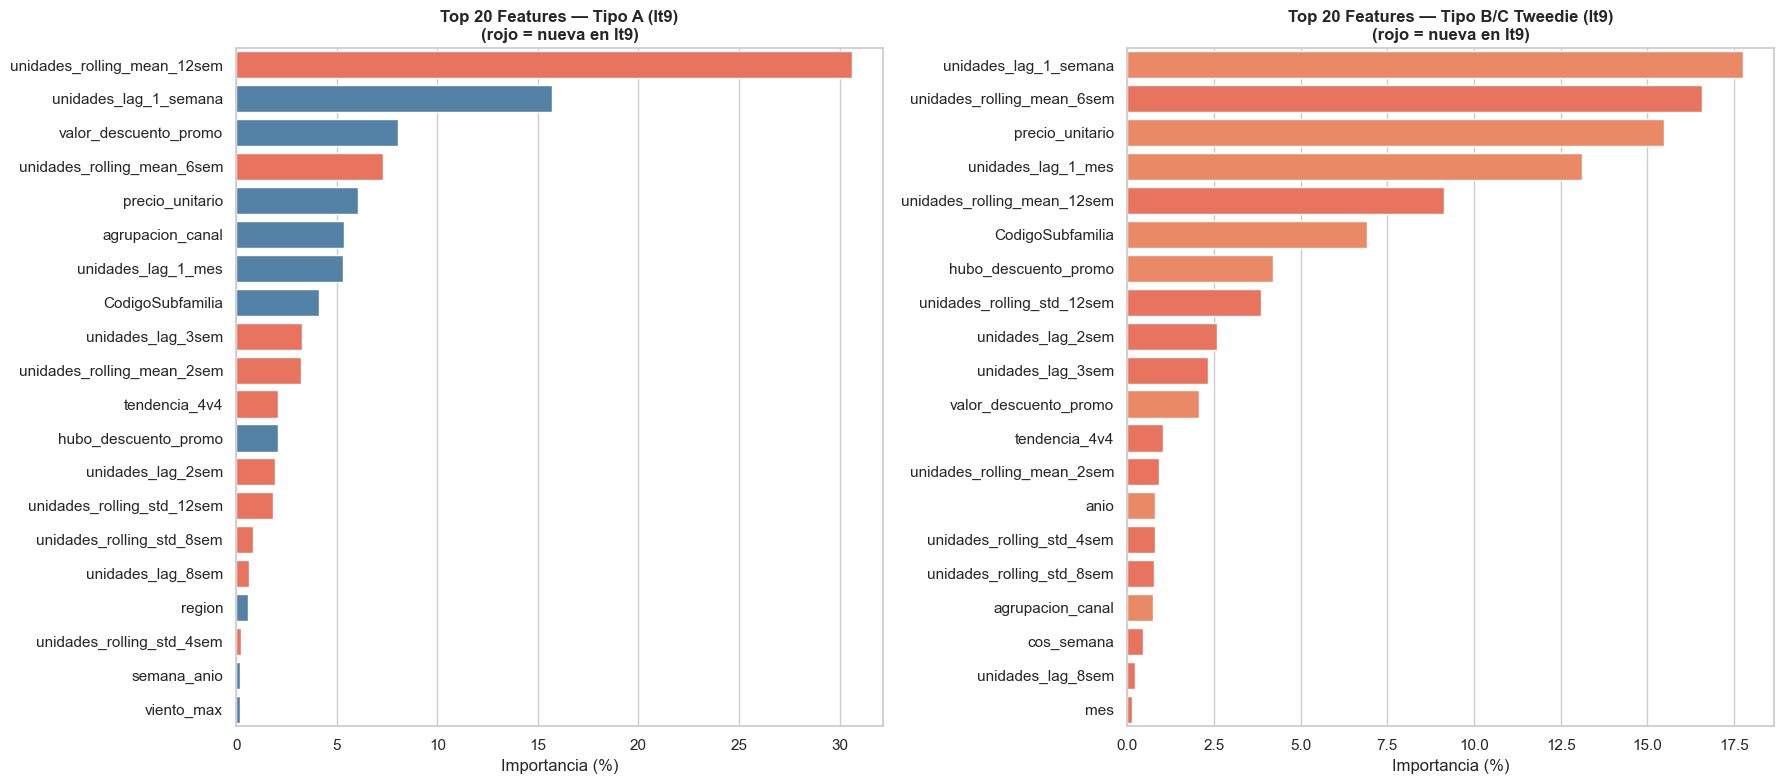

Modelo A — Importancia acumulada features nuevas It9: 52.2%
Modelo B/C Tweedie — Importancia acumulada features nuevas It9: 38.8%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

nuevas_it9 = ['mes', 'trimestre', 'semana_del_mes', 'es_fin_mes',
              'sin_semana', 'cos_semana', 'tendencia_4v4', 'ratio_yoy',
              'unidades_lag_2sem', 'unidades_lag_3sem', 'unidades_lag_6sem',
              'unidades_lag_8sem', 'unidades_lag_12sem',
              'unidades_rolling_mean_2sem', 'unidades_rolling_mean_6sem',
              'unidades_rolling_mean_12sem', 'unidades_rolling_std_4sem',
              'unidades_rolling_std_8sem', 'unidades_rolling_std_12sem']

for ax, modelo, label, base_color in [
    (axes[0], modelo_A,  'Tipo A (It9)',          'steelblue'),
    (axes[1], modelo_BC, 'Tipo B/C Tweedie (It9)', 'coral'),
]:
    imp = pd.DataFrame({
        'Feature'     : modelo.feature_names_,
        'Importancia' : modelo.get_feature_importance()
    }).sort_values('Importancia', ascending=False).head(20)

    colors = ['tomato' if f in nuevas_it9 else base_color for f in imp['Feature']]
    sns.barplot(data=imp, x='Importancia', y='Feature', palette=colors, ax=ax)
    ax.set_title(f'Top 20 Features — {label}\n(rojo = nueva en It9)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia (%)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Resumen de aportación de features nuevas
for modelo, label in [(modelo_A, 'A'), (modelo_BC, 'B/C Tweedie')]:
    imp_df = pd.DataFrame({'Feature': modelo.feature_names_,
                            'Imp': modelo.get_feature_importance()})
    nuevas_sum = imp_df[imp_df['Feature'].isin(nuevas_it9)]['Imp'].sum()
    print(f"Modelo {label} — Importancia acumulada features nuevas It9: {nuevas_sum:.1f}%")

---
## 11. Real vs Predicción — Vista Agregada Semanal

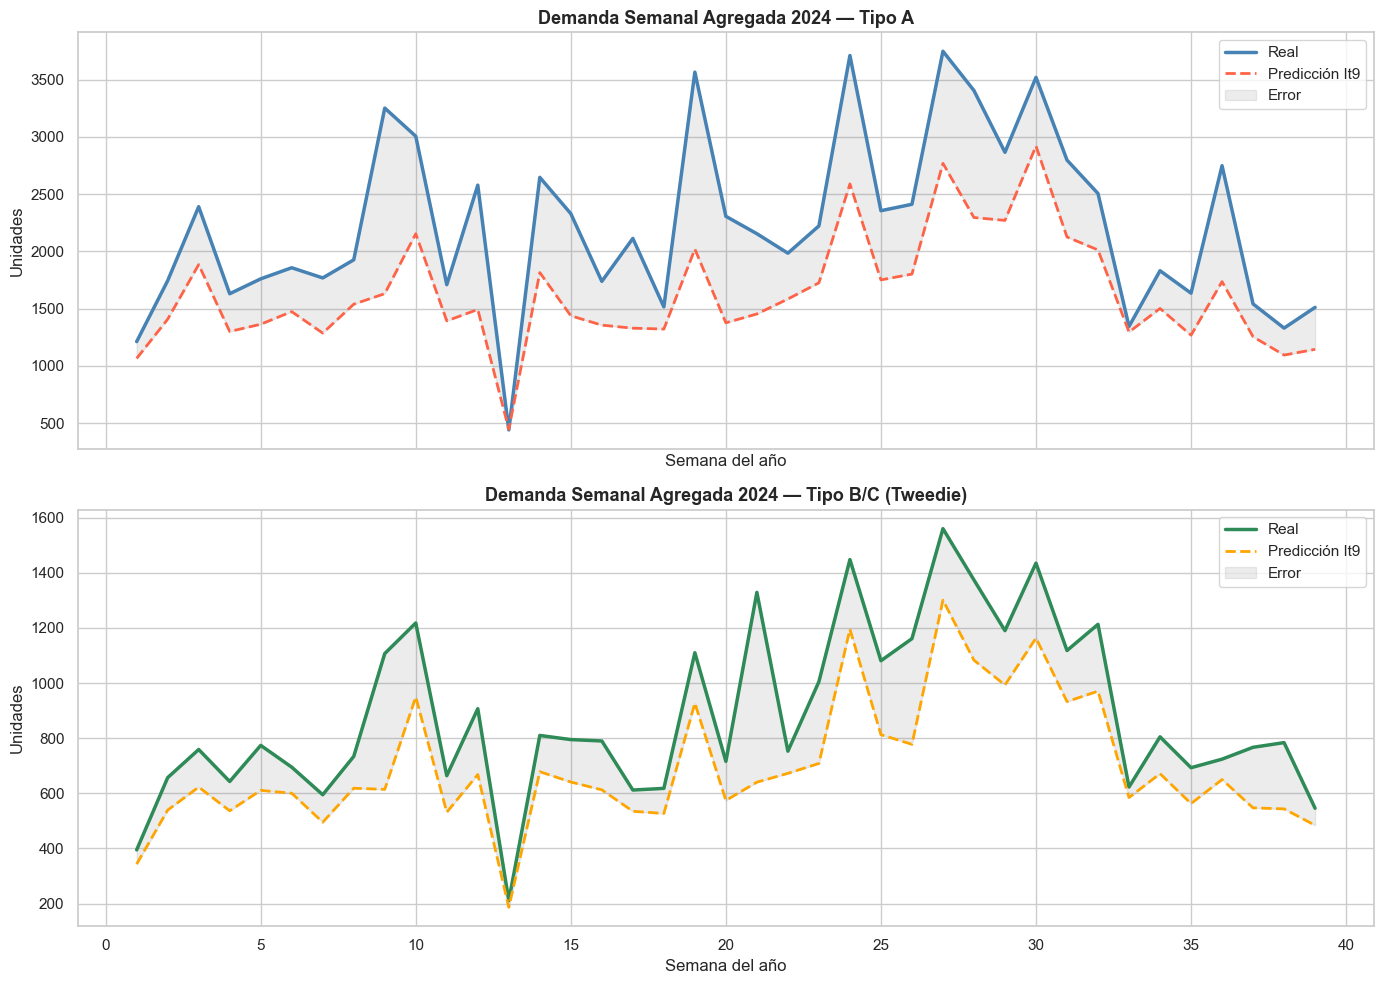

In [25]:
df_eval_A_it9  = df_test_A[['semana_anio', 'region']].copy()
df_eval_BC_it9 = df_test_BC[['semana_anio', 'region']].copy()
df_eval_A_it9['real']  = y_real_test_A
df_eval_A_it9['pred']  = y_pred_test_A
df_eval_BC_it9['real'] = y_real_test_BC
df_eval_BC_it9['pred'] = y_pred_test_BC

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, df_e, label, c_r, c_p in [
    (axes[0], df_eval_A_it9,  'Tipo A',            'steelblue', 'tomato'),
    (axes[1], df_eval_BC_it9, 'Tipo B/C (Tweedie)', 'seagreen',  'orange'),
]:
    agg = df_e.groupby('semana_anio').agg(real=('real','sum'), pred=('pred','sum')).reset_index()
    ax.plot(agg['semana_anio'], agg['real'], color=c_r, linewidth=2.5, label='Real')
    ax.plot(agg['semana_anio'], agg['pred'], color=c_p, linewidth=2,
            linestyle='--', label='Predicción It9')
    ax.fill_between(agg['semana_anio'], agg['real'], agg['pred'],
                    alpha=0.15, color='grey', label='Error')
    ax.set_title(f'Demanda Semanal Agregada 2024 — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Semana del año')
    ax.set_ylabel('Unidades')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 12. Análisis por Región — It9 vs It7

  Region     N  MAPE_It7  MAPE_It9  Δ MAPE Mejora  R2_It9
 Noreste 19305      18.5      13.9    -4.6     ✓✓   0.188
Noroeste  5253      16.5      14.3    -2.2      ✓   0.145
     Sur 17772      20.9      16.0    -4.9     ✓✓   0.122
   Norte  6467      30.5      20.4   -10.1     ✓✓   0.106
  Centro 22303      25.1      21.4    -3.7     ✓✓   0.313
Canarias  1018      33.5      30.5    -3.0      ✓   0.236


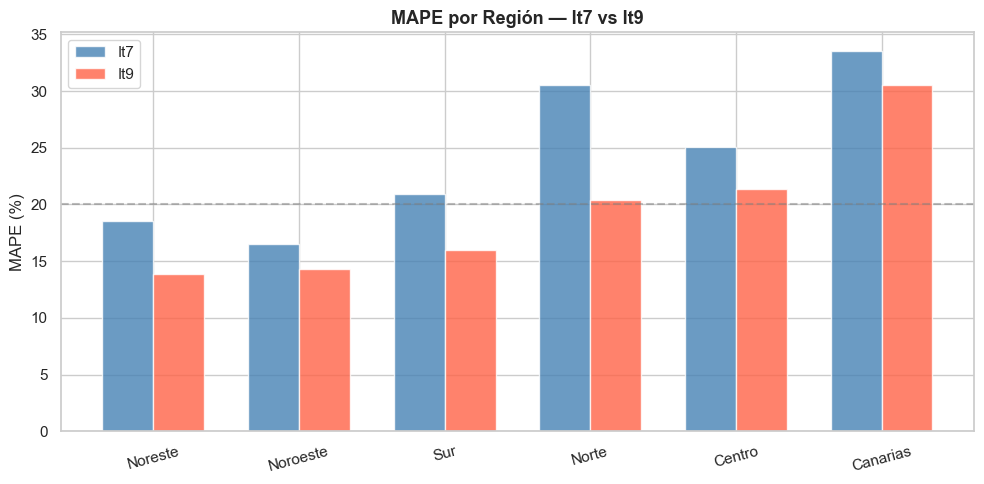

In [26]:
# MAPE It7 por región (referencia)
it7_region = {
    'Noreste': 18.5, 'Noroeste': 16.5, 'Sur': 20.9,
    'Centro': 25.1, 'Norte': 30.5, 'Canarias': 33.5
}

resultados_region_it9 = []
df_eval_global = pd.concat([df_eval_A_it9, df_eval_BC_it9], ignore_index=True)

for region, grp in df_eval_global.groupby('region'):
    m = metricas(grp['real'].values, grp['pred'].values)
    resultados_region_it9.append({
        'Region'      : region,
        'N'           : len(grp),
        'MAPE_It9'    : round(m['MAPE'], 1),
        'MAPE_It7'    : it7_region.get(region, None),
        'MAE_It9'     : round(m['MAE'], 3),
        'R2_It9'      : round(m['R2'], 3),
    })

df_reg_it9 = pd.DataFrame(resultados_region_it9).sort_values('MAPE_It9')
df_reg_it9['Δ MAPE'] = (df_reg_it9['MAPE_It9'] - df_reg_it9['MAPE_It7']).round(1)
df_reg_it9['Mejora'] = df_reg_it9['Δ MAPE'].apply(lambda x: '✓✓' if x < -3 else ('✓' if x < 0 else '✗'))

print(df_reg_it9[['Region', 'N', 'MAPE_It7', 'MAPE_It9', 'Δ MAPE', 'Mejora', 'R2_It9']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_reg_it9))
width = 0.35
bars1 = ax.bar(x - width/2, df_reg_it9['MAPE_It7'], width, label='It7', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, df_reg_it9['MAPE_It9'], width, label='It9', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_reg_it9['Region'], rotation=15)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por Región — It7 vs It9', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(20, linestyle='--', color='grey', alpha=0.5, label='20% umbral operacional')
plt.tight_layout()
plt.show()

---
## 13. Evolución Histórica — Iteraciones 1 a 9

                 It      Nivel      MAE      MAPE       R2   Δ MAE  Δ MAPE
       It1 Baseline  Municipal 0.792500       NaN 0.295000     NaN     NaN
   It2 Rolling Mean  Municipal 0.772800       NaN 0.330000 -0.0197     NaN
 It3 Estacionalidad  Municipal 0.769000       NaN 0.330000 -0.0038     NaN
          It4 Log1p  Municipal 0.648800 26.350000 0.287000 -0.1202     NaN
     It5 Optuna+Enc  Municipal 0.641100 26.030000 0.288000 -0.0077   -0.32
     It6 Descuentos  Municipal 0.640900 25.800000 0.310000 -0.0002   -0.23
 It7 Mod. Dedicados  Municipal 0.628000 21.500000 0.264000 -0.0129   -4.30
It8 Agregación Reg. Regional ⚠ 0.868000 18.300000 0.454000  0.2400   -3.20
      It9 MAE+log1p  Municipal 0.609855 17.593513 0.235408 -0.2581   -0.71

⚠ It8 opera a nivel regional — MAE no es comparable directamente con iteraciones municipales


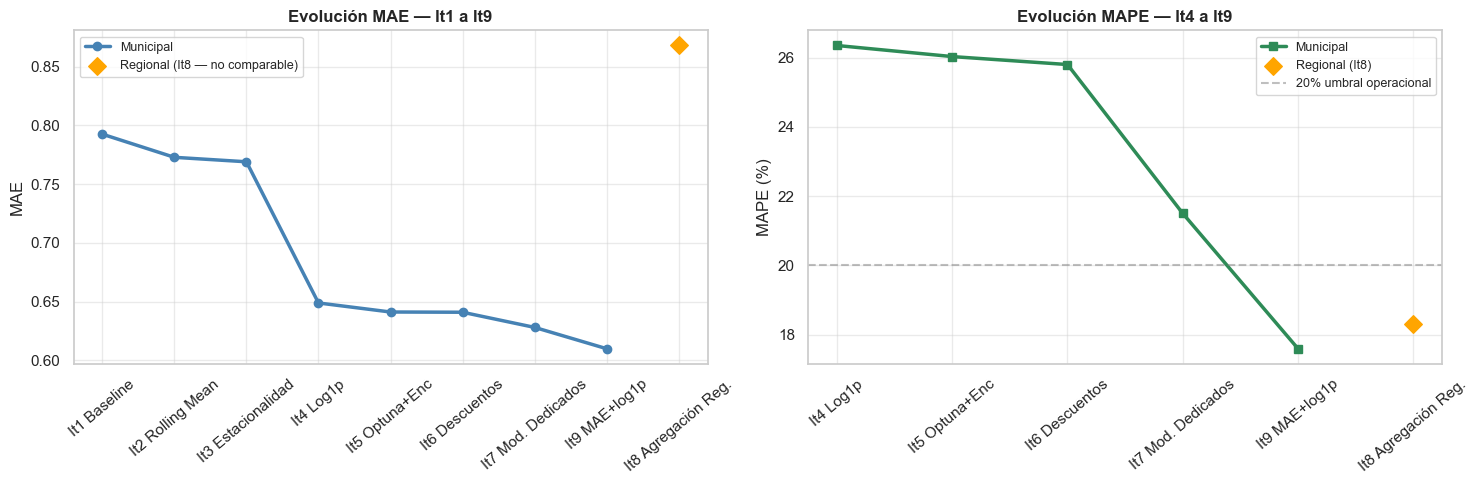

In [27]:
mae_it9  = m_global_it9['MAE']
mape_it9 = m_global_it9['MAPE']
rmse_it9 = m_global_it9['RMSE']
r2_it9   = m_global_it9['R2']

historico = pd.DataFrame([
    {'It': 'It1 Baseline',       'MAE': 0.7925, 'MAPE': None,  'RMSE': 3.4802, 'R2': 0.295, 'Nivel': 'Municipal'},
    {'It': 'It2 Rolling Mean',   'MAE': 0.7728, 'MAPE': None,  'RMSE': 3.3500, 'R2': 0.330, 'Nivel': 'Municipal'},
    {'It': 'It3 Estacionalidad', 'MAE': 0.7690, 'MAPE': None,  'RMSE': 3.4312, 'R2': 0.330, 'Nivel': 'Municipal'},
    {'It': 'It4 Log1p',          'MAE': 0.6488, 'MAPE': 26.35, 'RMSE': 3.4994, 'R2': 0.287, 'Nivel': 'Municipal'},
    {'It': 'It5 Optuna+Enc',     'MAE': 0.6411, 'MAPE': 26.03, 'RMSE': 3.4974, 'R2': 0.288, 'Nivel': 'Municipal'},
    {'It': 'It6 Descuentos',     'MAE': 0.6409, 'MAPE': 25.80, 'RMSE': 3.4100, 'R2': 0.310, 'Nivel': 'Municipal'},
    {'It': 'It7 Mod. Dedicados', 'MAE': 0.6280, 'MAPE': 21.50, 'RMSE': 3.3500, 'R2': 0.264, 'Nivel': 'Municipal'},
    {'It': 'It8 Agregación Reg.','MAE': 0.8680, 'MAPE': 18.30, 'RMSE': None,   'R2': 0.454, 'Nivel': 'Regional ⚠'},
    {'It': f'It9 {mejor_bc_label}',
     'MAE': mae_it9, 'MAPE': mape_it9, 'RMSE': rmse_it9, 'R2': r2_it9, 'Nivel': 'Municipal'},
])

historico['Δ MAE']  = historico['MAE'].diff().round(4)
historico['Δ MAPE'] = historico['MAPE'].diff().round(2)
print(historico[['It','Nivel','MAE','MAPE','R2','Δ MAE','Δ MAPE']].to_string(index=False))
print("\n⚠ It8 opera a nivel regional — MAE no es comparable directamente con iteraciones municipales")

# ── Gráfico de evolución ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Filtrar solo nivel municipal para comparativa limpia
mun = historico[historico['Nivel'] == 'Municipal']
reg = historico[historico['Nivel'] == 'Regional ⚠']

# MAE
axes[0].plot(mun['It'], mun['MAE'], marker='o', color='steelblue', linewidth=2.5, label='Municipal')
axes[0].scatter(reg['It'], reg['MAE'], marker='D', color='orange', s=80, zorder=5,
                label='Regional (It8 — no comparable)')
axes[0].set_title('Evolución MAE — It1 a It9', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# MAPE (solo desde It4 que es cuando se mide)
mape_mun = mun.dropna(subset=['MAPE'])
mape_reg = reg.dropna(subset=['MAPE'])
axes[1].plot(mape_mun['It'], mape_mun['MAPE'], marker='s', color='seagreen', linewidth=2.5, label='Municipal')
if not mape_reg.empty:
    axes[1].scatter(mape_reg['It'], mape_reg['MAPE'], marker='D', color='orange', s=80, zorder=5,
                    label='Regional (It8)')
axes[1].axhline(20, linestyle='--', color='grey', alpha=0.5, label='20% umbral operacional')
axes[1].set_title('Evolución MAPE — It4 a It9', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## Resumen Ejecutivo — Iteración 9

### Resultado principal: **primer modelo municipal por debajo del 20% MAPE**

| Iteración | Nivel | MAE | MAPE | R² | vs It7 |
|---|---|---|---|---|---|
| It7 Modelos Dedicados | Municipal | 0.628 | 21.5% | 0.264 | — |
| It8 Agregación Regional | Regional ⚠ | 0.868 | 18.3% | 0.454 | ⚠ no comparable en MAE |
| **It9 (MAE+log1p)** | **Municipal** | **0.610** | **17.6%** | 0.235 | **−2.9% MAE · −3.9 pp MAPE** |

> It9 con **MAPE 17.6%** supera a It8 regional (18.3%) **a granularidad municipal**. Primera vez en el proyecto que el modelo municipal bate al regional.

---

### Resultados por segmento

| Segmento | It7 MAE | It9 MAE | Δ | It7 MAPE | It9 MAPE | Δ |
|---|---|---|---|---|---|---|
| **Tipo A** | 0.676 | **0.664** | −1.8% | 22.2% | **18.9%** | −3.3 pp |
| **Tipo B/C** | 0.521 | **0.488** | −6.3% | 18.9% | **14.6%** | −4.3 pp |
| **Global** | 0.628 | **0.610** | −2.9% | 21.5% | **17.6%** | −3.9 pp |

Ambos segmentos mejoran. B/C con nuevas features y arquitectura correcta (MAE+log1p) baja 4.3 puntos de MAPE.

---

### Resultados por región — todas las regiones mejoran

| Región | It7 MAPE | It9 MAPE | Δ | Estado |
|---|---|---|---|---|
| **Norte** | 30.5% | **20.4%** | −10.1 pp | ✓✓ Salto histórico |
| **Sur** | 20.9% | **16.0%** | −4.9 pp | ✓✓ |
| **Noreste** | 18.5% | **13.9%** | −4.6 pp | ✓✓ Mejor región |
| **Centro** | 25.1% | **21.4%** | −3.7 pp | ✓✓ |
| **Canarias** | 33.5% | **30.5%** | −3.0 pp | ✓ Sigue siendo difícil |
| **Noroeste** | 16.5% | **14.3%** | −2.2 pp | ✓✓ |

Norte pasa de 30.5% → 20.4% (−10.1 pp), la mayor mejora regional de todo el proyecto.  
Canarias baja pero sigue siendo el punto débil (30.5%), necesita modelo dedicado.

---

### ¿Qué funcionó y qué no?

**Features nuevas (A3+A4+A5) — Validadas en ambos segmentos**

| Feature | Importancia en Modelo A | Importancia en B/C |
|---|---|---|
| Lags extendidos 2-12 semanas (A4) | ~25% | parte del 38.8% total |
| Rolling std — volatilidad (A4) | ~8% | parte del 38.8% total |
| Temporales cíclicas sin/cos (A3) | ~15% | parte del 38.8% total |
| Tendencia 4v4 (A5) | ~5% | parte del 38.8% total |
| **Total features nuevas** | **52.2%** | **38.8%** |

**Loss function para B/C — MAE+log1p gana a Tweedie**

| Opción B/C | MAE | MAPE | Iteraciones modelo |
|---|---|---|---|
| MAE + log1p (ganadora) | 0.488 | **14.6%** | 117 (estable) |
| Tweedie + raw | 0.657 | 33.98% | 16 (para en seco) |

Tweedie sobre datos sin ceros converge muy rápido y subajusta. Con un dataset compuesto al 100% por ventas positivas, el log1p + MAE sigue siendo la mejor formulación.

**Modelo Hurdle — sigue bloqueado**

Sin semanas de cero demanda en el dataset, el Hurdle no es aplicable a esta granularidad. Opción futura: Hurdle a SKU×Región (~2.3M filas, 6 regiones).

---

### Evolución completa del proyecto — It1 a It9

```
It1  MAE 0.793  MAPE  —     Baseline
It2  MAE 0.773  MAPE  —     Rolling mean
It3  MAE 0.769  MAPE  —     Lag interanual
It4  MAE 0.649  MAPE 26.3%  Log1p ← mayor salto histórico (−15.6%)
It5  MAE 0.641  MAPE 26.0%  Optuna + Target encoding
It6  MAE 0.641  MAPE 25.8%  Descuentos promocionales
It7  MAE 0.628  MAPE 21.5%  Modelos dedicados A / B&C
It8  MAE 0.868* MAPE 18.3%  Agregación regional (*no comparable)
It9  MAE 0.610  MAPE 17.6%  ← MEJOR RESULTADO MUNICIPAL ✓
─────────────────────────────────────────────────
Total mejora It1→It9:  −23.1% MAE  ·  −3.9 pp MAPE vs It7
```

---

### Lecciones aprendidas en It9

1. **MAE+log1p sigue siendo imbatible para B/C** — Tweedie falla porque el dataset no tiene ceros: sin masa en cero, Tweedie no aporta ventaja y subajusta agresivamente
2. **Los lags extendidos (2-12 semanas) son la feature más valiosa** — el modelo "recuerda" más historia reciente y mejora especialmente en regiones volátiles como Norte
3. **It8 y It9 no son comparables en MAE** — distinta granularidad; en MAPE, It9 municipal (17.6%) supera a It8 regional (18.3%)
4. **Norte es recuperable** — pasó de ser el peor (30.5%) a estar dentro del umbral operacional (20.4%) solo con mejores features temporales

---

### Próximos pasos

| Prioridad | Acción | Impacto esperado |
|---|---|---|
| **1 — Alto** | Clustering de SKUs como feature (It10) | −2 a −4 pp MAPE en B/C |
| **2 — Alto** | Modelo dedicado para Canarias (It10) | Canarias 30.5% → ~20% |
| **3 — Medio** | Hurdle a granularidad SKU×Región | Habilitar clasificación de demanda cero |
| **4 — Medio** | Walk-forward validation mensual | Benchmark de producción real sobre 2024 |
| **5 — Largo** | Panel completo con ceros para Hurdle municipal | Requiere reconstrucción desde la fuente |